Datasets Loaded Successfully ✅

Customers Shape: (99441, 5)
Orders Shape: (99441, 8)
Order Items Shape: (112650, 7)
Payments Shape: (103886, 5)

Merged Dataset Shape: (99441, 13)

Missing Values:
 customer_unique_id          0
order_id                    0
order_purchase_timestamp    0
payment_value               1
dtype: int64

Final Master Shape: (99440, 4)


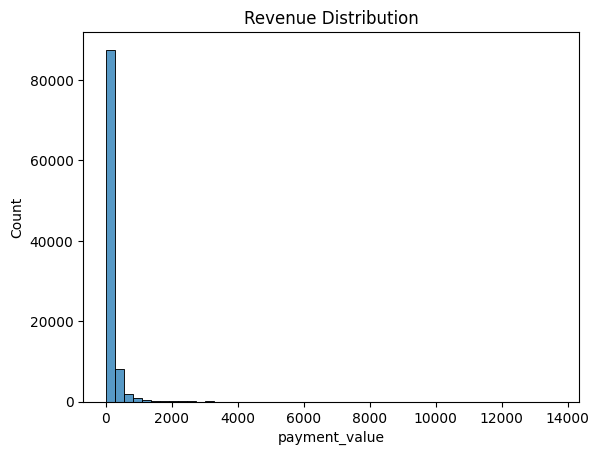

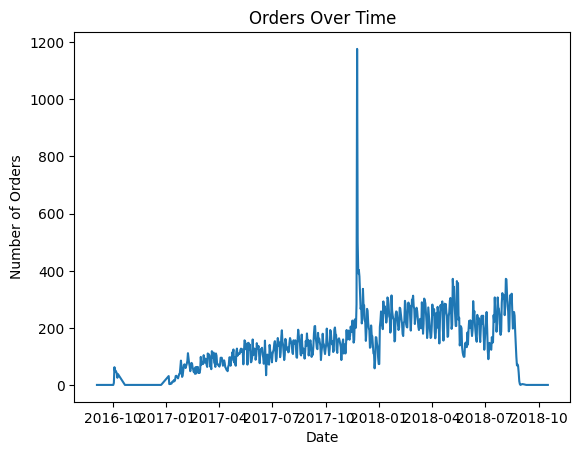


Master dataset created successfully ✅
                 customer_unique_id                          order_id  \
0  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
1  af07308b275d755c9edb36a90c618231  53cdb2fc8bc7dce0b6741e2150273451   
2  3a653a41f6f9fc3d2a113cf8398680e8  47770eb9100c2d0c44946d9cf07ec65d   
3  7c142cf63193a1473d2e66489a9ae977  949d5b44dbf5de918fe9c16f97b45f8a   
4  72632f0f9dd73dfee390c9b22eb56dd6  ad21c59c0840e6cb83a9ceb5573f8159   

  order_purchase_timestamp  payment_value  
0      2017-10-02 10:56:33          38.71  
1      2018-07-24 20:41:37         141.46  
2      2018-08-08 08:38:49         179.12  
3      2017-11-18 19:28:06          72.20  
4      2018-02-13 21:18:39          28.62  


In [ ]:
# 01_EDA.ipynb
# Customer Intelligence System - Data Preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1️⃣ Load datasets
# ----------------------------
customers = pd.read_csv(r"E:\Personal Project\customer-intelligence-system/Data/olist_customers_dataset.csv")
orders = pd.read_csv(r"E:\Personal Project\customer-intelligence-system/Data/olist_orders_dataset.csv")
order_items = pd.read_csv(r"E:\Personal Project\customer-intelligence-system/Data/olist_order_items_dataset.csv")
payments = pd.read_csv(r"E:\Personal Project\customer-intelligence-system/Data/olist_order_payments_dataset.csv")

print("Datasets Loaded Successfully ✅")

# ----------------------------
# 2️⃣ Basic Checks
# ----------------------------
print("\nCustomers Shape:", customers.shape)
print("Orders Shape:", orders.shape)
print("Order Items Shape:", order_items.shape)
print("Payments Shape:", payments.shape)

# ----------------------------
# 3️⃣ Convert Date Columns
# ----------------------------
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# ----------------------------
# 4️⃣ Aggregate Payments
# (Important: One order can have multiple payments)
# ----------------------------
payments_agg = payments.groupby("order_id")["payment_value"].sum().reset_index()

# ----------------------------
# 5️⃣ Merge Datasets
# ----------------------------
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")

print("\nMerged Dataset Shape:", df.shape)

# ----------------------------
# 6️⃣ Select Relevant Columns
# ----------------------------
master = df[[
    "customer_unique_id",
    "order_id",
    "order_purchase_timestamp",
    "payment_value"
]].copy()

# ----------------------------
# 7️⃣ Handle Missing Values
# ----------------------------
print("\nMissing Values:\n", master.isnull().sum())

master = master.dropna()

# ----------------------------
# 8️⃣ Remove Duplicates
# ----------------------------
master = master.drop_duplicates()

print("\nFinal Master Shape:", master.shape)

# ----------------------------
# 9️⃣ Basic EDA
# ----------------------------

# Revenue Distribution
plt.figure()
sns.histplot(master['payment_value'], bins=50)
plt.title("Revenue Distribution")
plt.show()

# Orders Over Time
orders_over_time = master.groupby(
    master['order_purchase_timestamp'].dt.date
)['order_id'].count()

plt.figure()
orders_over_time.plot()
plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.show()

# ----------------------------
# 🔟 Save Master Dataset
# ----------------------------
master.to_csv(r"E:\Personal Project\customer-intelligence-system/Data/master.csv", index=False)

print("\nMaster dataset created successfully ✅")
print(master.head())